# 02 - Elo Ratings

Fit the Elo model by replaying matches chronologically, then inspect the resulting ratings and a sample prediction.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.models import EloModel

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
elo = EloModel(config).fit(tr)
table = elo.ratings_table(teams)
table.head(20)

,team,rating,confederation,pot
0,Argentina,1711.675037,CONMEBOL,1
1,France,1677.221656,UEFA,1
2,Spain,1653.089301,UEFA,1
3,Germany,1647.945759,UEFA,1
4,Croatia,1639.110410,UEFA,1
5,Brazil,1638.591290,CONMEBOL,1
6,Morocco,1633.487895,CAF,1
7,England,1620.642189,UEFA,1
8,Colombia,1613.082684,CONMEBOL,1
9,Senegal,1603.850446,CAF,2


## Top 15 teams by Elo

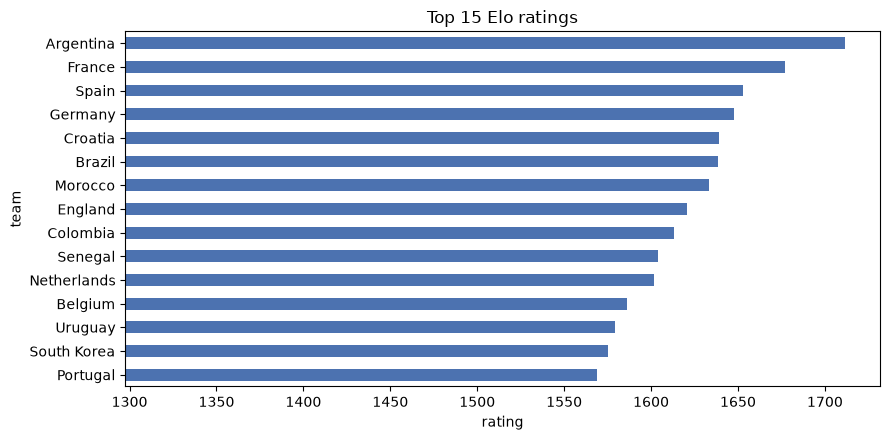

In [3]:
top = table.head(15).iloc[::-1]
ax = top.plot.barh(x='team', y='rating', legend=False, color='#4C72B0')
ax.set_title('Top 15 Elo ratings'); ax.set_xlabel('rating')
ax.set_xlim(table['rating'].min() - 20, table['rating'].max() + 20)
plt.tight_layout(); plt.show()

## Average rating by confederation

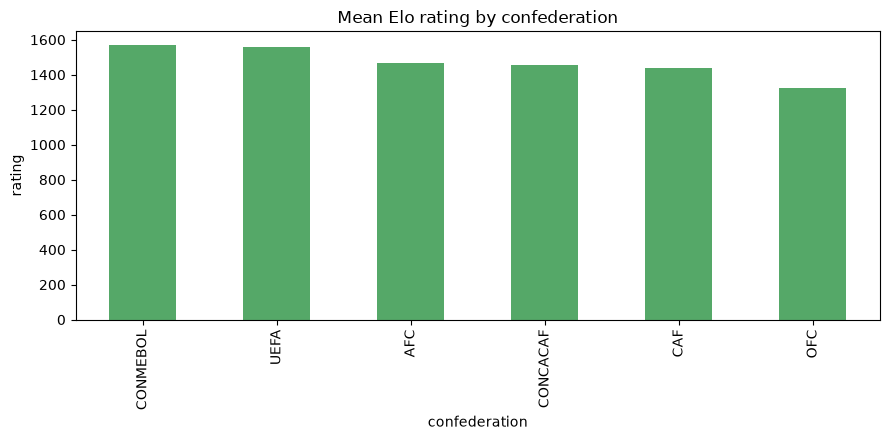

confederation
CONMEBOL    1569.756531
UEFA        1557.247979
AFC         1466.479467
CONCACAF    1455.332979
CAF         1441.229422
OFC         1322.885859
Name: rating, dtype: float64

In [4]:
by_conf = table.groupby('confederation')['rating'].mean().sort_values(ascending=False)
ax = by_conf.plot.bar(color='#55A868')
ax.set_title('Mean Elo rating by confederation')
ax.set_ylabel('rating'); plt.tight_layout(); plt.show()
by_conf

## Sample prediction

In [5]:
pred = elo.predict_match('Brazil', 'Germany', neutral=True)
print(f'Brazil win: {pred.p_home_win:.1%}')
print(f'Draw:       {pred.p_draw:.1%}')
print(f'Germany win:{pred.p_away_win:.1%}')

Brazil win: 35.5%
Draw:       26.3%
Germany win:38.2%
